In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [2]:
file_path = "/content/Customer_Churn_Data_Large.xlsx"
xls = pd.ExcelFile(file_path)

In [3]:
print("Available sheets:", xls.sheet_names)

Available sheets: ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [4]:
Customer_Demographics = xls.parse("Customer_Demographics")
Transaction_History = xls.parse("Transaction_History")
Customer_Service = xls.parse("Customer_Service")
Online_Activity = xls.parse("Online_Activity")
Churn_Status = xls.parse("Churn_Status")


In [6]:
df = Customer_Demographics.merge(Transaction_History, on='CustomerID', how='outer') \
                          .merge(Customer_Service, on='CustomerID', how='outer') \
                          .merge(Online_Activity, on='CustomerID', how='outer') \
                          .merge(Churn_Status, on='CustomerID', how='inner')


### **DATA** **CLEANING**


In [9]:
df['AmountSpent'] = df['AmountSpent'].fillna(0)
df['LoginFrequency'] = df['LoginFrequency'].fillna(0)
df['ProductCategory'] = df['ProductCategory'].fillna("Unknown")
df['ServiceUsage'] = df['ServiceUsage'].fillna("Unknown")

In [10]:
date_cols = ['TransactionDate', 'InteractionDate', 'LastLoginDate']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [11]:
df.drop_duplicates(inplace=True)

# **EDA**

**CHRUN DISTRIBUTION**

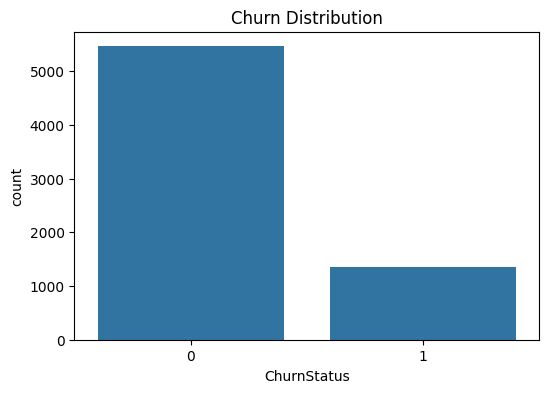

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='ChurnStatus', data=df)
plt.title("Churn Distribution")
plt.show()

**Histogram of Amount Spent**

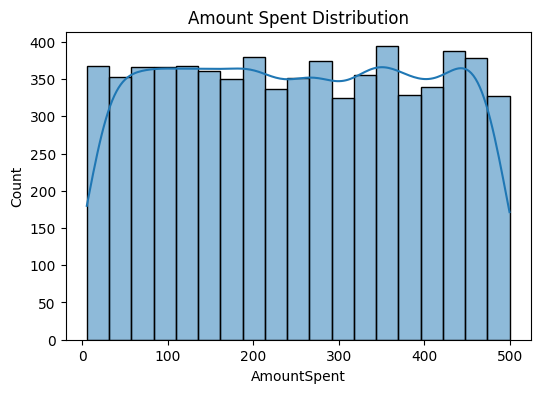

In [13]:
plt.figure(figsize=(6, 4))
sns.histplot(df['AmountSpent'], kde=True)
plt.title("Amount Spent Distribution")
plt.show()

**Boxplot of Login Frequency vs Churn**

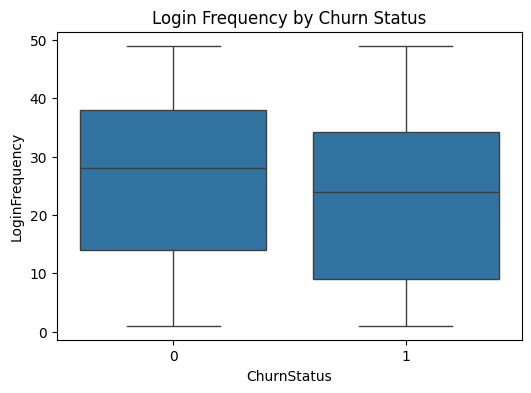

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=df)
plt.title("Login Frequency by Churn Status")
plt.show()


**Heatmap for correlations (only numerical)**

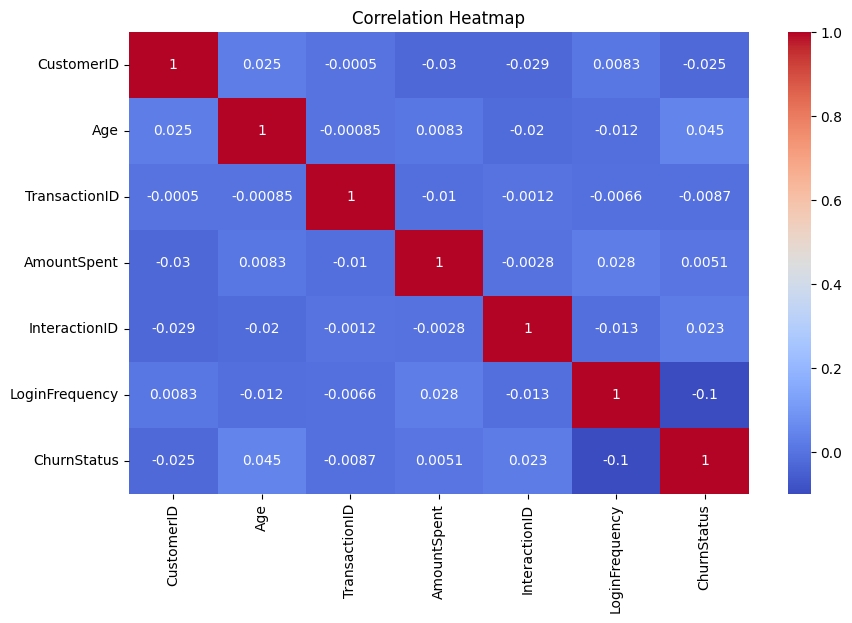

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **FEATURE ENGINEERING**

In [16]:
interaction_count = Customer_Service.groupby('CustomerID').size().reset_index(name='TotalInteractions')
df = df.merge(interaction_count, on='CustomerID', how='left')
df['TotalInteractions'] = df['TotalInteractions'].fillna(0)


In [17]:
df['DaysSinceLastLogin'] = (pd.to_datetime('today') - df['LastLoginDate']).dt.days
df['DaysSinceLastLogin'] = df['DaysSinceLastLogin'].fillna(df['DaysSinceLastLogin'].median())


In [19]:
features = ['AmountSpent', 'LoginFrequency', 'DaysSinceLastLogin', 'TotalInteractions', 'ProductCategory', 'ServiceUsage']
target = 'ChurnStatus'

X = df[features]
y = df[target]

In [20]:
numeric_features = ['AmountSpent', 'LoginFrequency', 'DaysSinceLastLogin', 'TotalInteractions']
categorical_features = ['ProductCategory', 'ServiceUsage']

In [21]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [23]:
X_processed = preprocessor.fit_transform(X)

**preprocessing completed. Ready for model development**